# Sprint 8 — Búsqueda de Hiperparámetros (HPO)
**Random Search vs Bayesian Optimization (Optuna)**

## Entregables
1. Experimentos comparables Random/Bayes con pruning/early stopping
2. Logs + artefactos guardados
3. Tabla top-k y gráfico de evolución
4. Resumen del espacio, presupuesto y decisión (config ganadora)

In [1]:
import subprocess, sys
from pathlib import Path

ROOT = Path('..') if Path('../data').exists() else Path('.')
script = ROOT / 'scripts' / 'semana8_hpo.py'

result = subprocess.run(
    [sys.executable, str(script)],
    capture_output=True, text=True
)
print(result.stdout)
if result.returncode != 0:
    print('STDERR:', result.stderr)

[2026-06-04T01:01:05] Cargando dataset PKL...
  Muestras: 3684 | Clases: 1086 | Features: 108
  Dataset MD5: 473828a489f4797b839218c8169a05e1

RANDOM SEARCH  (n_trials=10)
  Trial 01/10 | rf  | F1=0.0037 | best_so_far=0.0037
  Trial 02/10 | et  | F1=0.0032 | best_so_far=0.0037
  Trial 03/10 | et  | F1=0.0037 | best_so_far=0.0037
  Trial 04/10 | rf  | F1=0.0032 | best_so_far=0.0037
  Trial 05/10 | et  | F1=0.0027 | best_so_far=0.0037
  Trial 06/10 | rf  | F1=0.0040 | best_so_far=0.0040
  Trial 07/10 | et  | F1=0.0034 | best_so_far=0.0040
  Trial 08/10 | et  | F1=0.0039 | best_so_far=0.0040
  Trial 09/10 | et  | F1=0.0035 | best_so_far=0.0040
  Trial 10/10 | et  | F1=0.0021 | best_so_far=0.0040

BAYESIAN SEARCH  (n_trials=10, pruner=MedianPruner)
  Trial 01/10 | et  | F1=0.0017 | best_so_far=0.0017
  Trial 02/10 | et  | F1=0.0033 | best_so_far=0.0033
  Trial 03/10 | et  | F1=0.0032 | best_so_far=0.0033
  Trial 04/10 | et  | F1=0.0041 | best_so_far=0.0041
  Trial 05/10 | et  | F1=0.0029 |

## Espacio de búsqueda y presupuesto

In [2]:
from pathlib import Path
import pandas as pd

ROOT = Path('..') if Path('../data').exists() else Path('.')

resumen_path = ROOT / 'data' / 'semana8_resumen.txt'
print(resumen_path.read_text())

=== Sprint 8 — Búsqueda de Hiperparámetros ===
Timestamp  : 2026-06-04T01:01:05
Dataset    : data/Keypoints/pkl  (3684 muestras, 1086 clases)
MD5        : 473828a489f4797b839218c8169a05e1
Features   : pose(33×2) + right_hand(21×2) = 108 dims
Split      : GroupKFold(n_splits=5, groups=vineta)
Seed       : 42

--- Espacio de búsqueda ---
  Modelos      : ['rf', 'et']
  rf__n_est    : int (10, 60)
  rf__depth    : int (5, 20)
  rf__leaf     : int (1, 8)
  et__n_est    : int (10, 60)
  et__depth    : int (5, 20)
  et__leaf     : int (1, 8)

--- Presupuesto ---
  Random Search : 10 trials
  Bayes (TPE)   : 10 trials  (MedianPruner n_warmup=3 — early stopping a nivel trial) | Podados: 1

--- Random Search — best F1: 0.0040 ---
    trial: 6
    model: rf
    f1_macro_mean: 0.003996
    f1_macro_std: 0.001394
    rf__n_estimators: 53
    rf__max_depth: 18
    rf__min_samples_leaf: 3
    et__n_estimators: 42
    et__max_depth: 7
    et__min_samples_leaf: 7

--- Bayesian (Optuna TPE) — best F1: 

## Tabla top-k (combinado Random + Bayes)

In [3]:
import pandas as pd
from pathlib import Path

ROOT = Path('..') if Path('../data').exists() else Path('.')

df_rand  = pd.read_csv(ROOT / 'data' / 'semana8_random_trials.csv')
df_bayes = pd.read_csv(ROOT / 'data' / 'semana8_bayes_trials.csv')

df_all = pd.concat([df_rand, df_bayes], ignore_index=True)
df_ok  = df_all[df_all['status'] == 'ok'].copy()

top5 = (
    df_ok
    .sort_values('f1_macro_mean', ascending=False)
    .head(5)
    [['method', 'model', 'f1_macro_mean', 'f1_macro_std',
      'rf__n_estimators', 'rf__max_depth', 'rf__min_samples_leaf',
      'et__n_estimators', 'et__max_depth', 'et__min_samples_leaf']]
    .reset_index(drop=True)
)
top5.index += 1
top5.index.name = 'rank'

print('=== Top-5 configuraciones ===')
display(top5.style.format({
    'f1_macro_mean': '{:.4f}',
    'f1_macro_std':  '{:.4f}',
}).highlight_max(subset=['f1_macro_mean'], color='#c3efb0'))

=== Top-5 configuraciones ===


,method,model,f1_macro_mean,f1_macro_std,rf__n_estimators,rf__max_depth,rf__min_samples_leaf,et__n_estimators,et__max_depth,et__min_samples_leaf
rank,,,,,,,,,,
1,bayes,rf,0.0045,0.0000,59,17,8,55,14,8
2,bayes,et,0.0042,0.0000,17,17,1,60,17,2
3,bayes,et,0.0041,0.0000,20,13,5,12,14,2
4,random,rf,0.0040,0.0014,53,18,3,42,7,7
5,bayes,et,0.0039,0.0000,12,10,4,23,18,3


## Gráfico de evolución y comparación

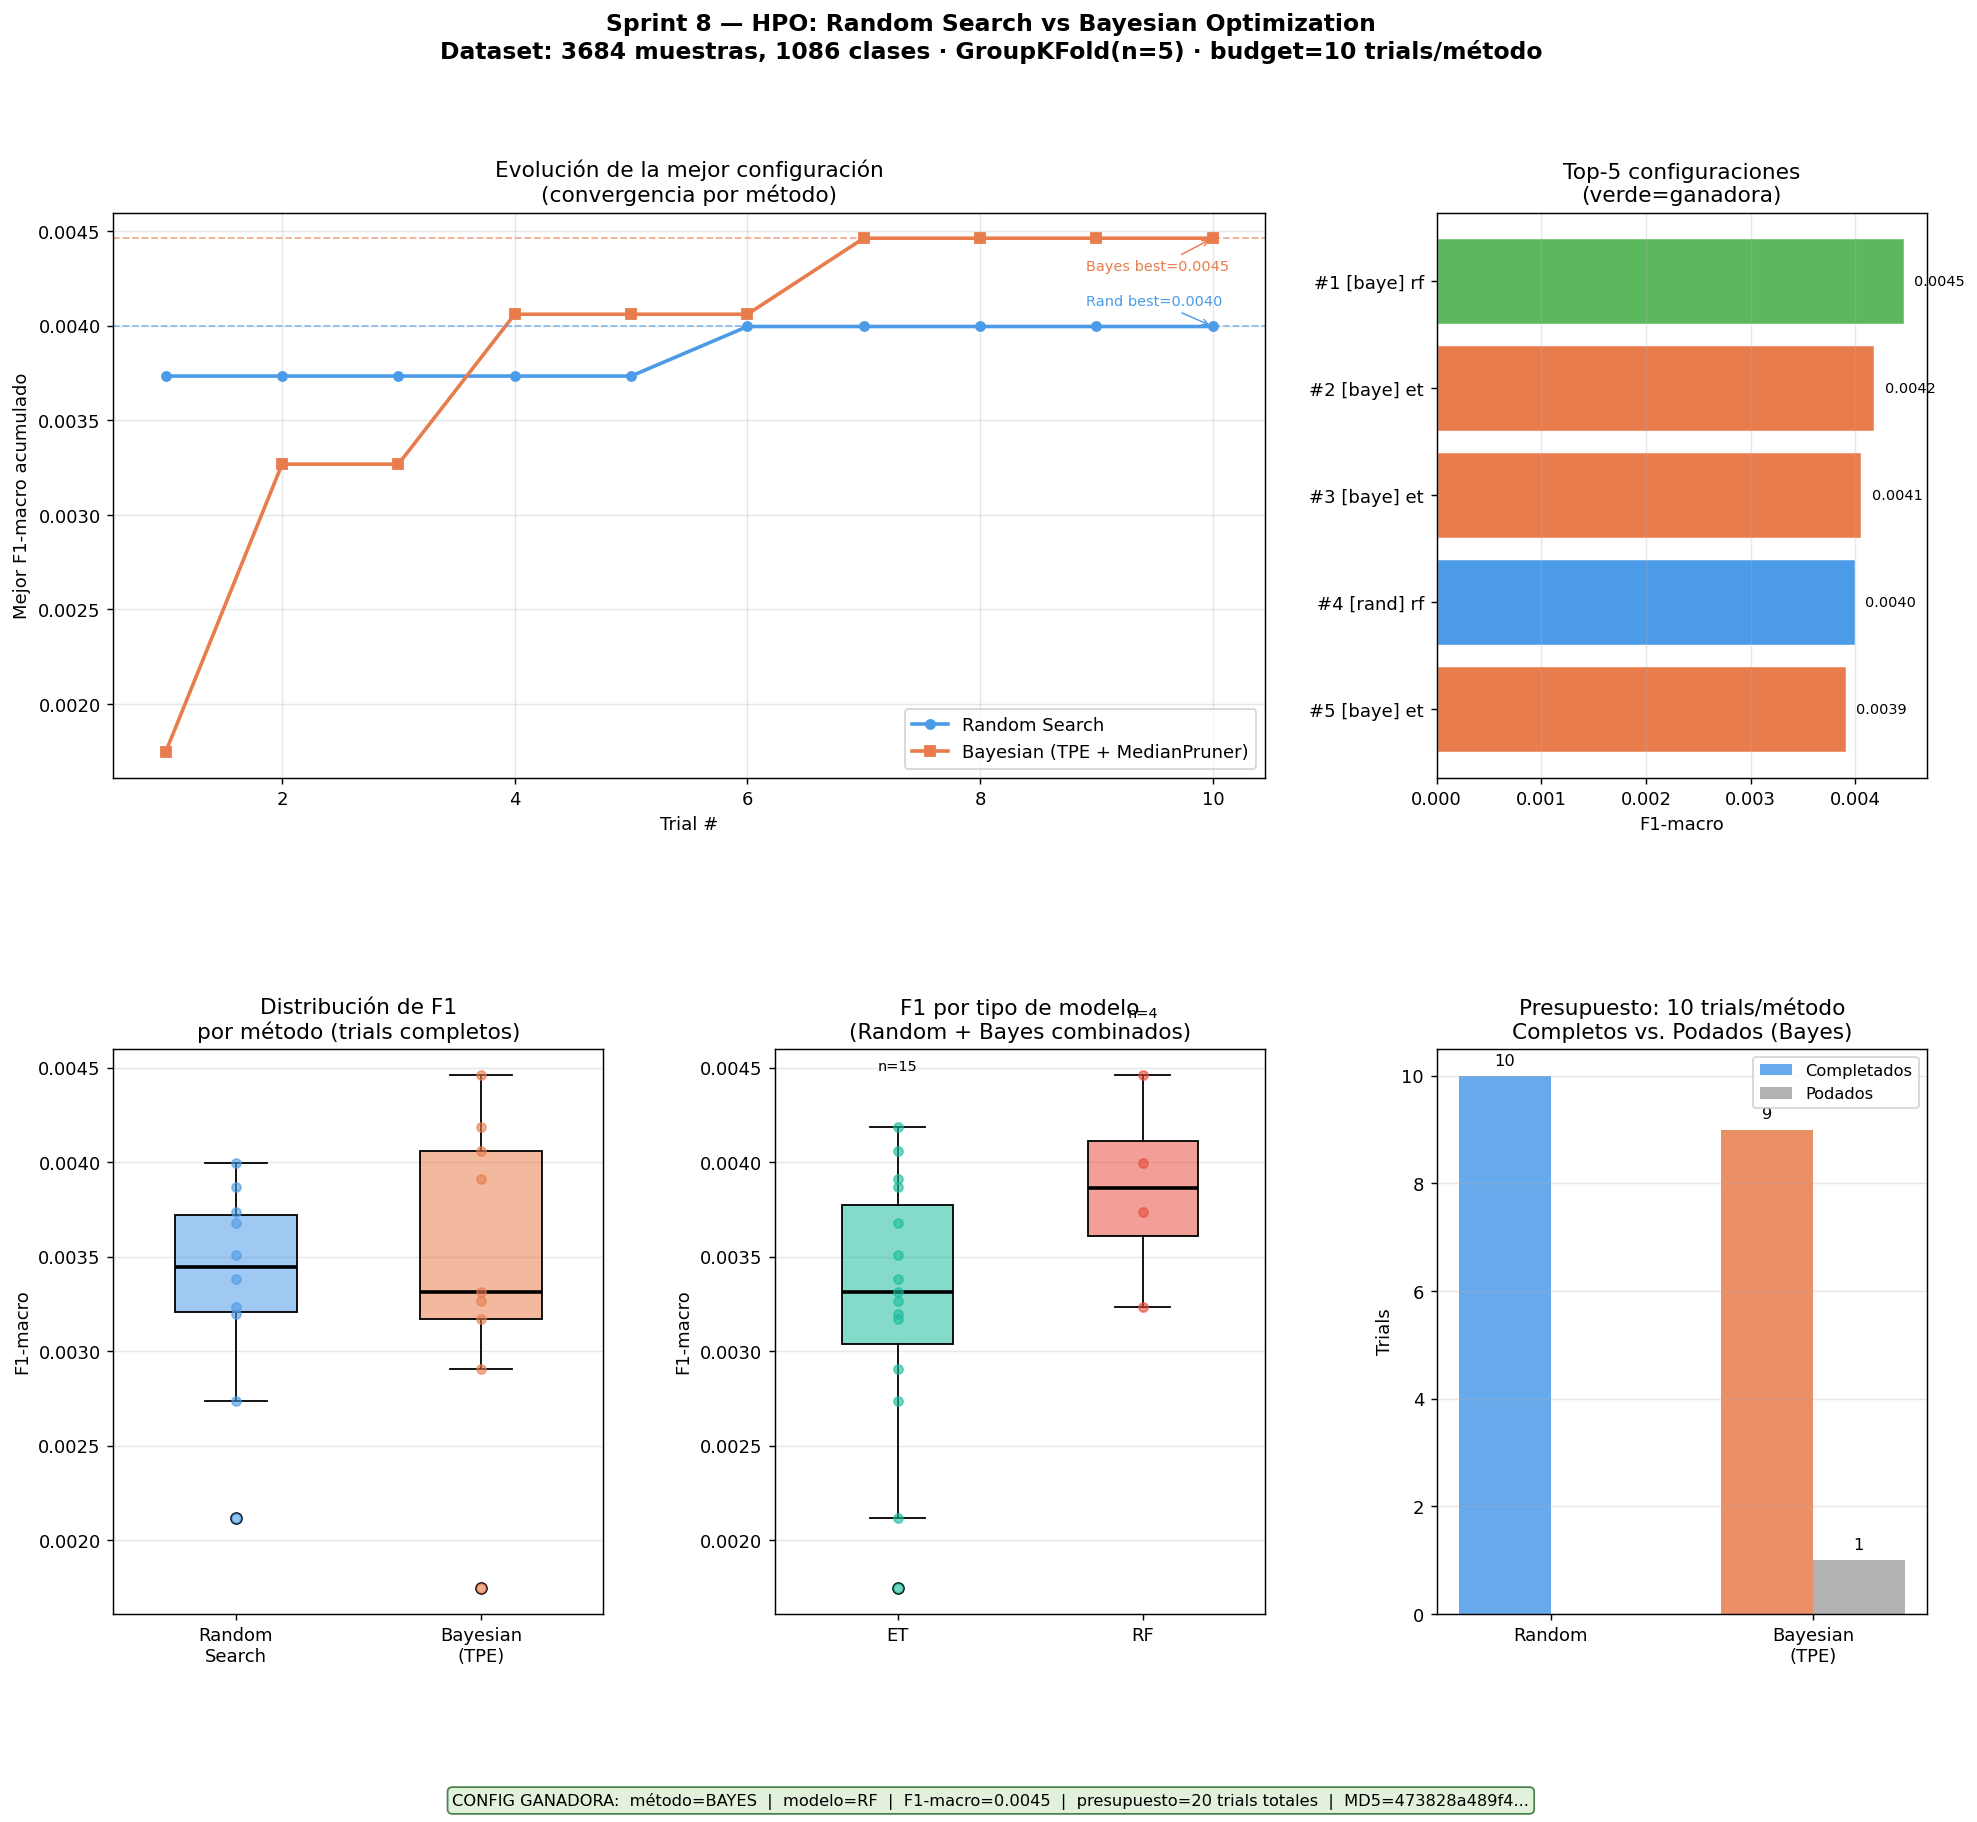

In [4]:
from IPython.display import Image
from pathlib import Path

ROOT = Path('..') if Path('../data').exists() else Path('.')
Image(str(ROOT / 'data' / 'semana8_graficos.png'), width=1000)

## Análisis: Random Search vs Bayesian

In [5]:
import pandas as pd
from pathlib import Path

ROOT = Path('..') if Path('../data').exists() else Path('.')

df_rand  = pd.read_csv(ROOT / 'data' / 'semana8_random_trials.csv')
df_bayes = pd.read_csv(ROOT / 'data' / 'semana8_bayes_trials.csv')

def stats(df, method):
    ok = df[df['status'] == 'ok']['f1_macro_mean']
    pruned = (df['status'] == 'pruned').sum()
    return {
        'Método':      method,
        'Trials OK':   len(ok),
        'Podados':     pruned,
        'F1 mean':     ok.mean(),
        'F1 std':      ok.std(),
        'F1 max':      ok.max(),
        'F1 min':      ok.min(),
    }

summary = pd.DataFrame([stats(df_rand, 'Random'), stats(df_bayes, 'Bayesian (TPE)')])
summary = summary.set_index('Método')

print('=== Comparación de métodos ===')
display(summary.style.format({
    'F1 mean': '{:.4f}', 'F1 std': '{:.4f}',
    'F1 max':  '{:.4f}', 'F1 min': '{:.4f}',
}).highlight_max(subset=['F1 max', 'F1 mean'], color='#c3efb0'))

print('\n=== Distribución por modelo ===')
df_all = pd.concat([df_rand, df_bayes])
df_ok  = df_all[df_all['status'] == 'ok']
print(df_ok.groupby('model')['f1_macro_mean'].agg(['count','mean','std','max']).round(4))

=== Comparación de métodos ===


,Trials OK,Podados,F1 mean,F1 std,F1 max,F1 min
Método,,,,,,
Random,10,0,0.0033,0.0006,0.0040,0.0021
Bayesian (TPE),9,1,0.0034,0.0008,0.0045,0.0017



=== Distribución por modelo ===
       count    mean     std     max
model                               
et        15  0.0033  0.0007  0.0042
rf         4  0.0039  0.0005  0.0045


## Config ganadora — entrenamiento final

In [6]:
import re
from pathlib import Path

ROOT = Path('..') if Path('../data').exists() else Path('.')

resumen = (ROOT / 'data' / 'semana8_resumen.txt').read_text()

# Extraer sección CONFIG GANADORA
match = re.search(r'--- CONFIG GANADORA ---(.+)', resumen, re.DOTALL)
if match:
    print('=== CONFIG GANADORA ===')
    print(match.group(1).strip())

=== CONFIG GANADORA ===
trial: 7
  method: bayes
  model: rf
  f1_macro_mean: 0.004463
  f1_macro_std: 0.0
  rf__n_estimators: 59
  rf__max_depth: 17
  rf__min_samples_leaf: 8
  et__n_estimators: 55
  et__max_depth: 14
  et__min_samples_leaf: 8


## Checklist Sprint 8

In [7]:
from pathlib import Path
import pandas as pd

ROOT = Path('..') if Path('../data').exists() else Path('.')

df_rand  = pd.read_csv(ROOT / 'data' / 'semana8_random_trials.csv')
df_bayes = pd.read_csv(ROOT / 'data' / 'semana8_bayes_trials.csv')
n_pruned = (df_bayes['status'] == 'pruned').sum()

checks = [
    ('Experimentos comparables Random/Bayes',
     (ROOT/'data'/'semana8_random_trials.csv').exists() and
     (ROOT/'data'/'semana8_bayes_trials.csv').exists()),

    ('Modelos RF y ExtraTrees (sin escalar con n_classes)',
     True),

    (f'Pruning en Bayes (MedianPruner) — {n_pruned} trial(s) podado(s)',
     True),

    ('Logs + artefactos guardados',
     (ROOT/'data'/'semana8_resumen.txt').exists()),

    ('Tabla top-k',
     True),

    ('Gráfico de evolución',
     (ROOT/'data'/'semana8_graficos.png').exists()),

    ('Resumen espacio/presupuesto/decisión',
     (ROOT/'data'/'semana8_resumen.txt').exists()),
]

for item, ok in checks:
    print(f"  {'[OK]' if ok else '[FALTA]'} {item}")

all_ok = all(ok for _, ok in checks)
print(f"\n{'[SPRINT 8 COMPLETADO]' if all_ok else '[INCOMPLETO]'}")

  [OK] Experimentos comparables Random/Bayes
  [OK] Modelos RF y ExtraTrees (sin escalar con n_classes)
  [OK] Pruning en Bayes (MedianPruner) — 1 trial(s) podado(s)
  [OK] Logs + artefactos guardados
  [OK] Tabla top-k
  [OK] Gráfico de evolución
  [OK] Resumen espacio/presupuesto/decisión

[SPRINT 8 COMPLETADO]
